# PhysREVE — Leadfield Physics Visualization

This notebook visualises **why the leadfield attention bias helps** by comparing:

- **REVE** — standard self-attention, no physics knowledge
- **PhysREVE** — same attention + $\alpha B$ where $B = L_{\text{row}}\,L_{\text{row}}^\top$

The forward model of EEG is:
$$\mathbf{y} = L \cdot \mathbf{s} + \varepsilon$$

| Symbol | Shape | Meaning |
|---|---|---|
| $\mathbf{y}$ | $(C \times T)$ | Observed EEG at $C$ electrodes |
| $L$ | $(C \times N)$ | Leadfield — maps $N$ brain sources to electrodes |
| $\mathbf{s}$ | $(N \times T)$ | Latent cortical source activations |

The PhysREVE attention bias is:
$$B_{ij} = (L_{\text{row}})_i \cdot (L_{\text{row}})_j = \cos(\ell_i,\, \ell_j) \in [-1, 1]$$

$B_{ij} \approx 1$ means electrodes $i$ and $j$ see the same cortical sources — the transformer should attend strongly between them.

In [1]:
import subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    repo = '/content/PhysREVE'
    if not os.path.exists(repo):
        subprocess.check_call(['git', 'clone', '-q', 'https://github.com/UgoBruzadin/PhysREVE.git', repo])
    else:
        subprocess.check_call(['git', '-C', repo, 'pull', '-q'])
    if repo not in sys.path:
        sys.path.insert(0, repo)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'mne>=1.6', 'moabb>=1.0', 'xgboost'])
    print('Colab environment ready.')
else:
    print('Local environment — ensure you ran: pip install -e .')

Colab environment ready.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from physreve.physics import build_leadfield, motor_roi_indices
from physreve.datasets.bciv2a import CH_NAMES, SFREQ

N_CH = len(CH_NAMES)
print(f'Channels: {N_CH}  ({CH_NAMES[:5]} ...)')

Channels: 22  (['Fz', 'FC3', 'FC1', 'FCz', 'FC2'] ...)


## 1. Build Leadfield

Uses MNE's 3-shell sphere conductor model — no individual MRI required.
The sphere is fitted automatically to the electrode positions.

- **Shell 1 — Brain:** innermost, cortical sources live here
- **Shell 2 — Skull:** high-resistance barrier, smears source signals
- **Shell 3 — Scalp:** where electrodes sit

We also get back the **raw leadfield** $L$ for visualisation.

In [3]:
L_col_np, L_row_np, src_pos, info, L_raw = build_leadfield(
    CH_NAMES, sfreq=SFREQ, verbose=True, return_raw=True
)

# Attention bias matrix  B = L_row @ L_row^T
B = L_row_np @ L_row_np.T   # (n_ch, n_ch) cosine similarity

# Motor ROI source indices
lh_idx_np, rh_idx_np = motor_roi_indices(info, src_pos, CH_NAMES)

# Electrode positions in metres
elec_np = np.array([info['chs'][i]['loc'][:3] for i in range(N_CH)])

print(f'\nLeadfield L        : {L_raw.shape}  (n_ch × n_src)')
print(f'Attention bias B   : {B.shape}  (n_ch × n_ch)')
print(f'Source positions   : {src_pos.shape}')
print(f'LH motor sources   : {len(lh_idx_np)}')
print(f'RH motor sources   : {len(rh_idx_np)}')

  Source space: 1496 active dipoles


  Leadfield shape: (22, 1496)

Leadfield L        : (22, 1496)  (n_ch × n_src)
Attention bias B   : (22, 22)  (n_ch × n_ch)
Source positions   : (1496, 3)
LH motor sources   : 84
RH motor sources   : 83


## 2. Visualization

Three panels telling a single physics story:

1. **3-Shell sphere model** — how a cortical source's signal reaches the scalp electrodes (the physics $\mathbf{y} = L\mathbf{s}$)
2. **Leadfield matrix $L$** — each row is one electrode's sensitivity profile across all brain sources; similar rows mean correlated electrodes
3. **Attention bias $B = L_{\text{row}}L_{\text{row}}^\top$** — dot-product of rows from ②; this is what gets added to the transformer attention logits in PhysREVE

> REVE skips steps ② and ③ entirely — its transformer has no knowledge of this structure.

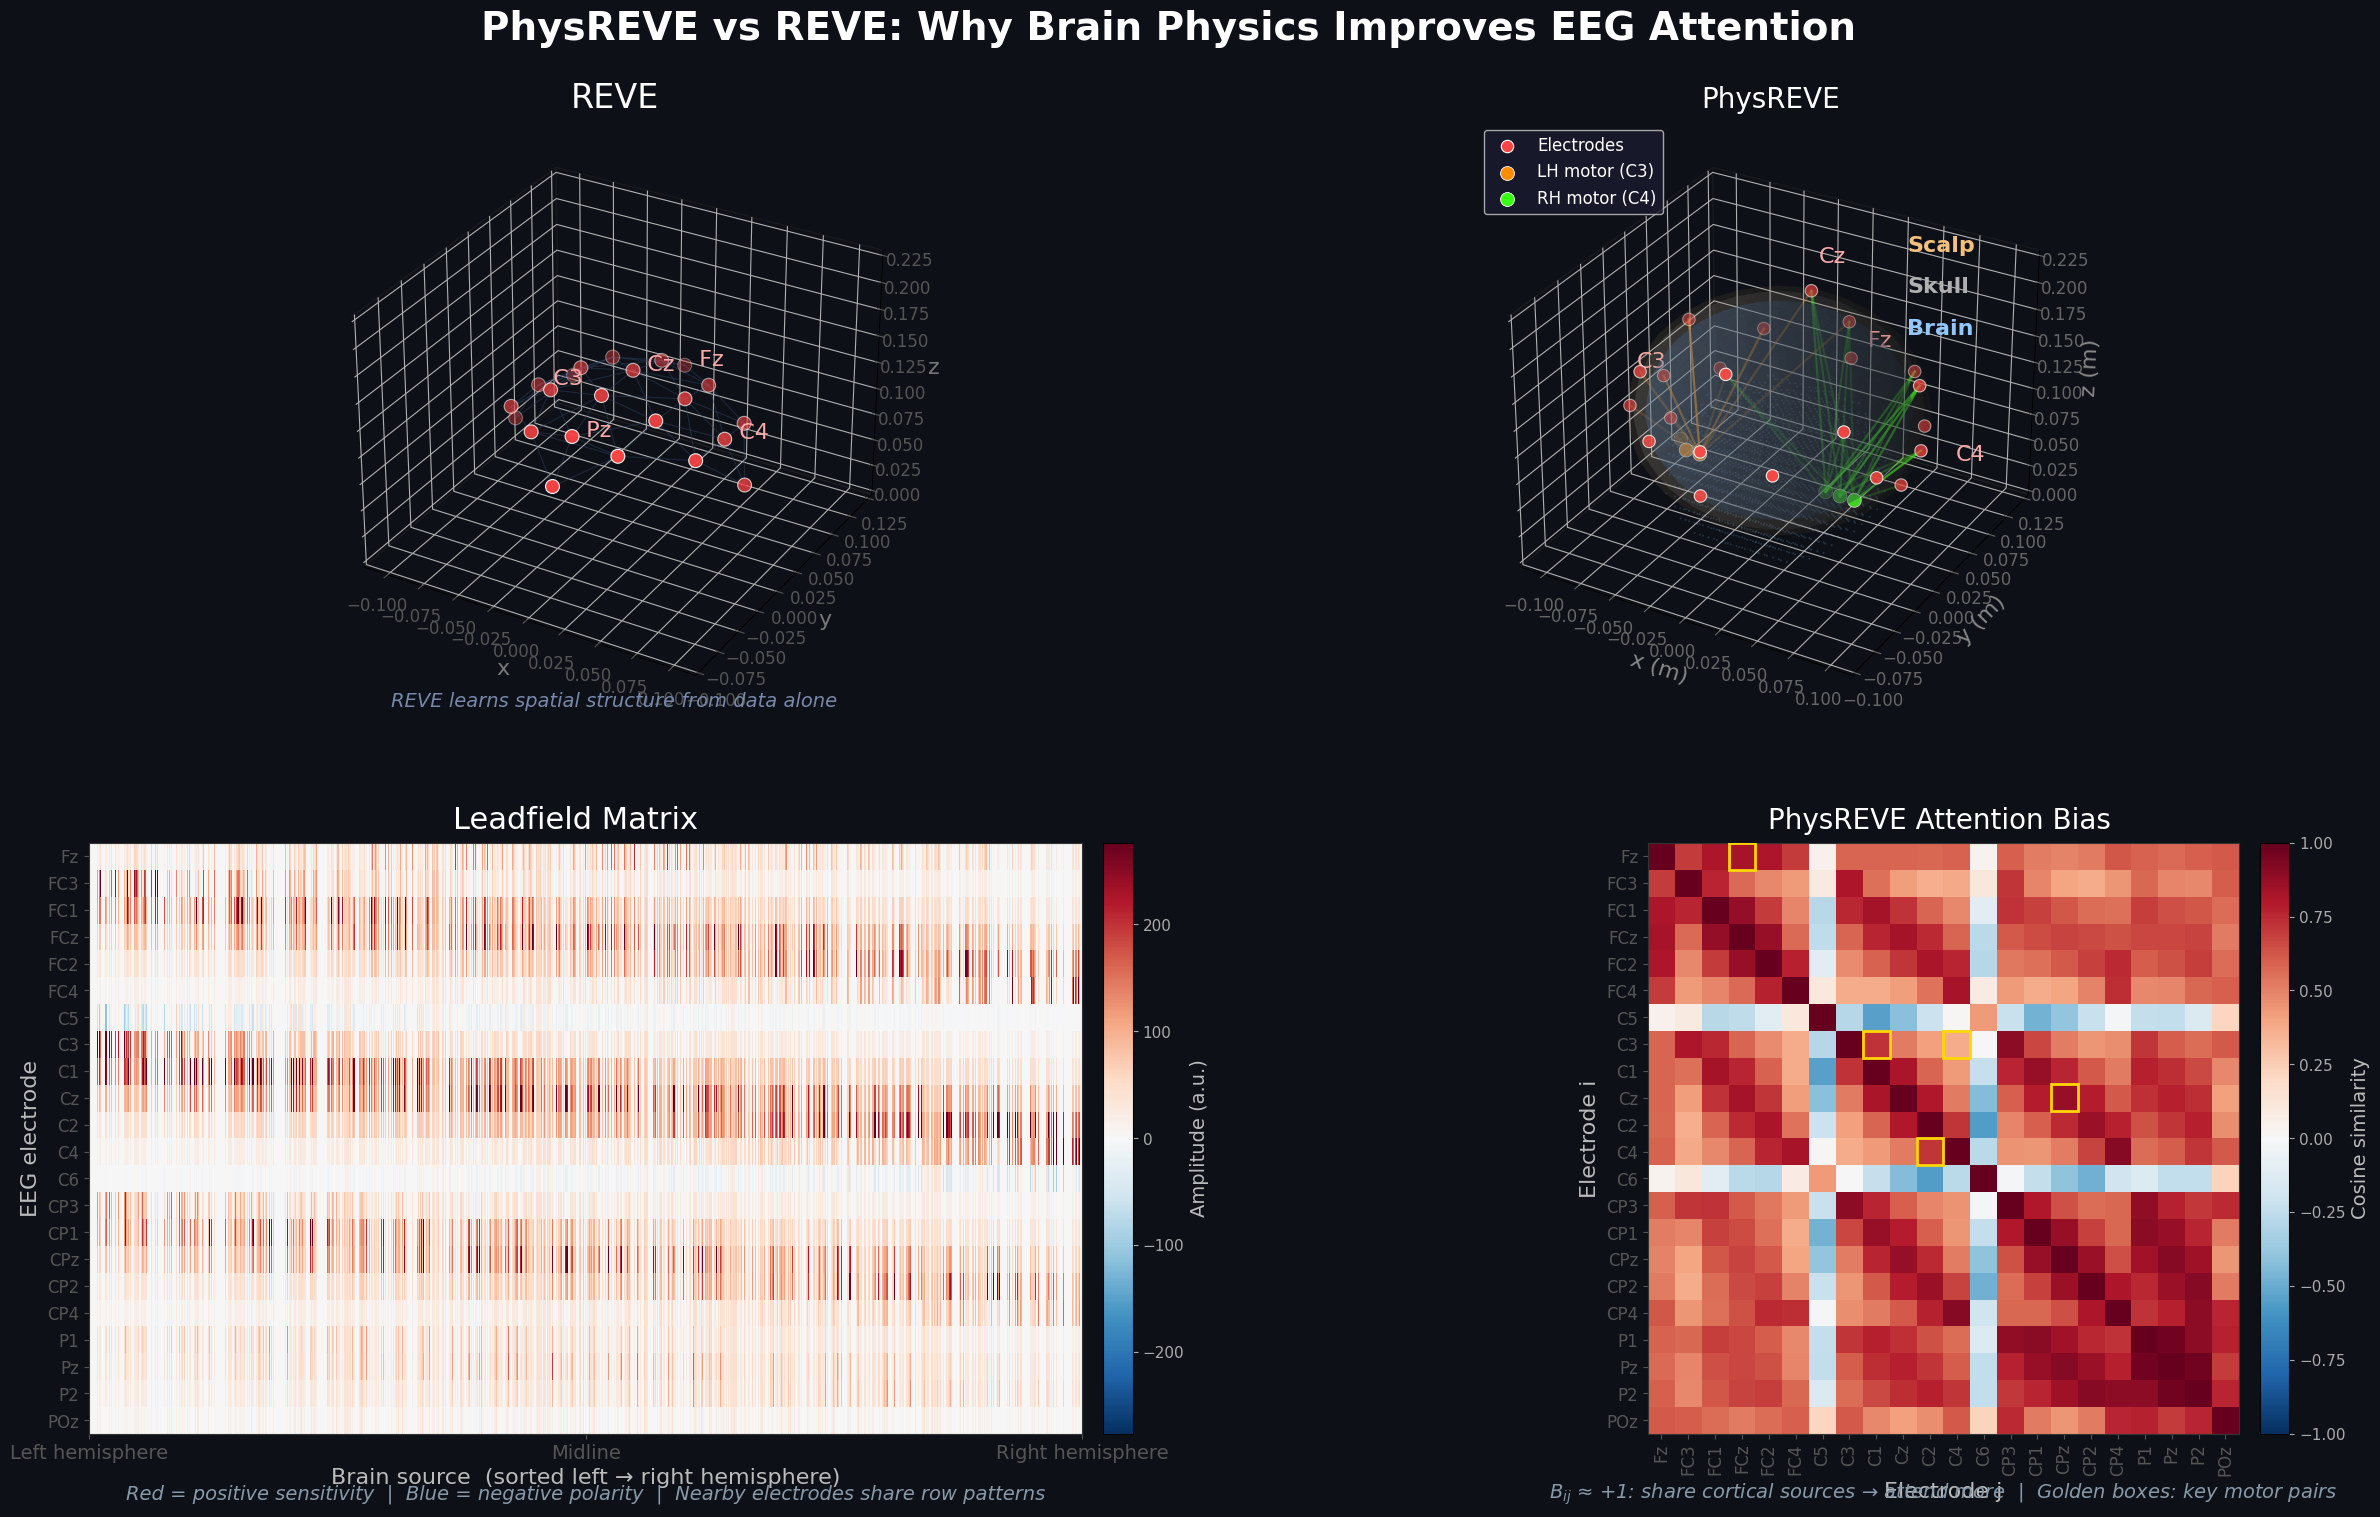

Saved physreve_leadfield_vis.png


In [5]:
# ── Helper: draw a transparent sphere ────────────────────────────────────────
def _draw_sphere(ax, r, ctr, color, alpha, n=28):
    u, v = np.mgrid[0:2*np.pi:n*1j, 0:np.pi:n*1j]
    x = r * np.cos(u) * np.sin(v) + ctr[0]
    y = r * np.sin(u) * np.sin(v) + ctr[1]
    z = r * np.cos(v)              + ctr[2]
    ax.plot_surface(x, y, z, color=color, alpha=alpha,
                    linewidth=0, antialiased=True, shade=True)

def _project_to_sphere(positions, center, radius):
    dirs  = positions - center
    norms = np.linalg.norm(dirs, axis=1, keepdims=True).clip(min=1e-10)
    return center + dirs / norms * radius

# ── Geometry ──────────────────────────────────────────────────────────────────
elec_np_loc   = np.array([info['chs'][i]['loc'][:3] for i in range(N_CH)])
_ctr          = elec_np_loc.mean(axis=0)
_dists        = np.linalg.norm(elec_np_loc - _ctr, axis=1)
r_scalp       = _dists.max()
r_skull       = r_scalp * 0.956
r_brain       = r_scalp * 0.878
elec_on_scalp = _project_to_sphere(elec_np_loc, _ctr, r_scalp)
src_order     = np.argsort(src_pos[:, 0])

# ── Global font sizes ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size':        14,
    'axes.titlesize':   20,
    'axes.labelsize':   16,
    'xtick.labelsize':  12,
    'ytick.labelsize':  12,
    'legend.fontsize':  12,
    'figure.titlesize': 26,
})

# ── Figure ────────────────────────────────────────────────────────────────────
BG  = '#0d1117'
fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor(BG)
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.22, wspace=0.10,
                        left=0.05, right=0.97, top=0.91, bottom=0.09)

ax1 = fig.add_subplot(gs[0, 0], projection='3d')
ax2 = fig.add_subplot(gs[0, 1], projection='3d')
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

for ax in [ax1, ax2]:
    ax.set_facecolor(BG)
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    for spine in [ax.xaxis, ax.yaxis, ax.zaxis]:
        spine.pane.set_edgecolor('#222')
for ax in [ax3, ax4]:
    ax.set_facecolor(BG)

_lim = r_scalp * 1.25

# ── Panel 1: REVE — Electrodes floating in space ─────────────────────────────
ax1.set_title('REVE',# No Physics — Electrodes Float in Space\nNo brain geometry, all pairs treated equally',
              color='white', fontsize=24, pad=10)

for i in range(N_CH):
    for j in range(i + 1, N_CH):
        d = np.linalg.norm(elec_np_loc[i] - elec_np_loc[j])
        if d < r_scalp * 0.65:
            ax1.plot([elec_np_loc[i, 0], elec_np_loc[j, 0]],
                     [elec_np_loc[i, 1], elec_np_loc[j, 1]],
                     [elec_np_loc[i, 2], elec_np_loc[j, 2]],
                     c='#334466', alpha=0.45, lw=0.8)

ax1.scatter(elec_np_loc[:, 0], elec_np_loc[:, 1], elec_np_loc[:, 2],
            c='#ff4444', s=100, zorder=6, linewidths=0.8, edgecolors='white')

for name in ['C3', 'C4', 'Cz', 'Fz', 'Pz']:
    if name in CH_NAMES:
        i = CH_NAMES.index(name)
        ax1.text(*elec_np_loc[i].tolist(), f'  {name}', color='#ffaaaa', fontsize=16)

ax1.set_xlim(_ctr[0]-_lim, _ctr[0]+_lim)
ax1.set_ylim(_ctr[1]-_lim, _ctr[1]+_lim)
ax1.set_zlim(_ctr[2]-_lim, _ctr[2]+_lim)
ax1.tick_params(colors='#555', labelsize=12)
ax1.set_xlabel('x', color='#777', fontsize=16, labelpad=4)
ax1.set_ylabel('y', color='#777', fontsize=16, labelpad=4)
ax1.set_zlabel('z', color='#777', fontsize=16, labelpad=4)
ax1.text2D(0.5, 0.01, 'REVE learns spatial structure from data alone',
           ha='center', transform=ax1.transAxes, color='#7788aa', fontsize=14, style='italic')

# ── Panel 2: PhysREVE — Brain + skull + scalp + electrodes ON scalp ──────────
ax2.set_title('PhysREVE',#: Head Model — Sources → Skull → Scalp\nLeadfield projects cortical activity to electrodes',
              color='white', fontsize=20, pad=10)

_draw_sphere(ax2, r_scalp, _ctr, '#f4c07a', 0.05)
_draw_sphere(ax2, r_skull, _ctr, '#b0b0b0', 0.09)
_draw_sphere(ax2, r_brain, _ctr, '#2a5fa0', 0.20)

ax2.scatter(src_pos[:, 0], src_pos[:, 1], src_pos[:, 2],
            c='#90c8ff', s=2, alpha=0.18, linewidths=0)

ax2.scatter(elec_on_scalp[:, 0], elec_on_scalp[:, 1], elec_on_scalp[:, 2],
            c='#ff4444', s=80, zorder=8, linewidths=0.8, edgecolors='white', label='Electrodes')

for name in ['C3', 'C4', 'Cz', 'Fz']:
    if name in CH_NAMES:
        i = CH_NAMES.index(name)
        v = elec_on_scalp[i] - _ctr
        ax2.text(*(_ctr + v * 1.24).tolist(), name, color='#ffaaaa', fontsize=16)

for roi_idx, clr, lbl in [(lh_idx_np, '#ff8c00', 'LH motor (C3)'),
                            (rh_idx_np, '#39ff14', 'RH motor (C4)')]:
    picks = roi_idx[:3]
    ax2.scatter(src_pos[picks, 0], src_pos[picks, 1], src_pos[picks, 2],
                c=clr, s=100, zorder=9, label=lbl, edgecolors='white', linewidths=0.6)
    for si in picks:
        col     = L_col_np[:, si]
        col_abs = np.abs(col)
        thresh  = col_abs.max() * 0.22
        strong  = np.where(col_abs > thresh)[0]
        if len(strong) == 0: continue
        norms_v = col_abs[strong] / col_abs[strong].max()
        for ei, nv in zip(strong, norms_v):
            ax2.plot([src_pos[si, 0], elec_on_scalp[ei, 0]],
                     [src_pos[si, 1], elec_on_scalp[ei, 1]],
                     [src_pos[si, 2], elec_on_scalp[ei, 2]],
                     c=clr, alpha=float(nv) * 0.72, lw=1.6)

ax2.set_xlim(_ctr[0]-_lim, _ctr[0]+_lim)
ax2.set_ylim(_ctr[1]-_lim, _ctr[1]+_lim)
ax2.set_zlim(_ctr[2]-_lim, _ctr[2]+_lim)
ax2.tick_params(colors='#666', labelsize=12)
ax2.set_xlabel('x (m)', color='#888', fontsize=16, labelpad=4)
ax2.set_ylabel('y (m)', color='#888', fontsize=16, labelpad=4)
ax2.set_zlabel('z (m)', color='#888', fontsize=16, labelpad=4)
ax2.legend(fontsize=12, loc='upper left', facecolor='#1a1a2e', labelcolor='white', framealpha=0.80)
for txt, clr, y in [('Scalp','#f4c07a',0.78),('Skull','#b0b0b0',0.71),('Brain','#90c8ff',0.64)]:
    ax2.text2D(0.73, y, txt, transform=ax2.transAxes, color=clr, fontsize=16, fontweight='bold')

# ── Panel 3: Leadfield matrix — fixed contrast ───────────────────────────────
vmax_L = np.percentile(np.abs(L_raw[:, src_order]), 99.5)
im3 = ax3.imshow(L_raw[:, src_order], aspect='auto', cmap='RdBu_r',
                  vmin=-vmax_L, vmax=vmax_L, interpolation='nearest')
ax3.set_title('Leadfield Matrix  ',#$L$\nElectrode sensitivity to every brain source',
               color='white', fontsize=22, pad=10)
ax3.set_xlabel('Brain source  (sorted left → right hemisphere)', color='#bbb', fontsize=16)
ax3.set_ylabel('EEG electrode', color='#bbb', fontsize=16)
ax3.set_yticks(range(N_CH))
ax3.set_yticklabels(CH_NAMES, fontsize=12, color='#ddd')
ax3.set_xticks([0, len(src_order)//2, len(src_order)-1])
ax3.set_xticklabels(['Left hemisphere', 'Midline', 'Right hemisphere'],
                     fontsize=14, color='#ccc')
ax3.tick_params(colors='#555')
for sp in ax3.spines.values(): sp.set_edgecolor('#333')
cb3 = plt.colorbar(im3, ax=ax3, fraction=0.035, pad=0.02)
cb3.set_label('Amplitude (a.u.)', color='#bbb', fontsize=14)
cb3.ax.yaxis.set_tick_params(color='#aaa', labelsize=11)
plt.setp(cb3.ax.yaxis.get_ticklabels(), color='#aaa')
ax3.text(0.5, -0.11,
    'Red = positive sensitivity  |  Blue = negative polarity  |  '
    'Nearby electrodes share row patterns',
    ha='center', transform=ax3.transAxes, fontsize=14, color='#8899aa', style='italic')

# ── Panel 4: Attention bias B ─────────────────────────────────────────────────
im4 = ax4.imshow(B, aspect='equal', cmap='RdBu_r', vmin=-1, vmax=1,
                  interpolation='nearest')
ax4.set_title(
    r'PhysREVE Attention Bias ', 
    #$B = L_{\mathrm{row}}\,L_{\mathrm{row}}^\top$' + '\n'
    #'Electrode-electrode cosine similarity added to attention logits',
    color='white', fontsize=20, pad=10)
ax4.set_xlabel('Electrode j', color='#bbb', fontsize=16)
ax4.set_ylabel('Electrode i', color='#bbb', fontsize=16)
ax4.set_xticks(range(N_CH))
ax4.set_xticklabels(CH_NAMES, fontsize=12, rotation=90, color='#ddd')
ax4.set_yticks(range(N_CH))
ax4.set_yticklabels(CH_NAMES, fontsize=12, color='#ddd')
ax4.tick_params(colors='#555')
for sp in ax4.spines.values(): sp.set_edgecolor('#333')
for (ni, nj) in [('C3','C4'), ('C3','C1'), ('C4','C2'), ('Cz','CPz'), ('Fz','FCz')]:
    if ni in CH_NAMES and nj in CH_NAMES:
        ii, jj = CH_NAMES.index(ni), CH_NAMES.index(nj)
        ax4.add_patch(plt.Rectangle((jj-0.5, ii-0.5), 1, 1,
                                     fill=False, edgecolor='#ffd700', lw=2.0, zorder=5))
cb4 = plt.colorbar(im4, ax=ax4, fraction=0.035, pad=0.02)
cb4.set_label('Cosine similarity', color='#bbb', fontsize=14)
cb4.ax.yaxis.set_tick_params(color='#aaa', labelsize=11)
plt.setp(cb4.ax.yaxis.get_ticklabels(), color='#aaa')
ax4.text(0.5, -0.11,
    r'$B_{ij}$ ≈ +1: share cortical sources → attend more  |  Golden boxes: key motor pairs',
    ha='center', transform=ax4.transAxes, fontsize=14, color='#8899aa', style='italic')

# ── Shared title ──────────────────────────────────────────────────────────────
fig.suptitle(
    'PhysREVE vs REVE: Why Brain Physics Improves EEG Attention\n',
    # r'$\mathbf{y} = L \cdot \mathbf{s} + \varepsilon$  —  REVE ignores $L$;  '
    # r'PhysREVE bakes it in via $B = L_{\mathrm{row}}L_{\mathrm{row}}^\top$',
    color='white', fontsize=28, fontweight='bold', y=0.98
)

plt.savefig('../physreve_leadfield_vis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved ../physreve_leadfield_vis.png')

## 3. How to Read the Plots

### Panel ①: 3-Shell Sphere Model
- **Red dots** = EEG electrodes on the scalp
- **Blue cloud** = all brain source dipoles
- **Orange / green lines** = how LH and RH motor sources project to electrodes — each line's opacity is proportional to that electrode's sensitivity to the source
- The skull shell acts as a resistive barrier, spreading each source's signal across many electrodes

### Panel ②: Leadfield Matrix $L$
- Rows = electrodes, columns = brain sources (sorted left→right hemisphere)
- **Red** = electrode is positively sensitive to that source; **Blue** = negatively sensitive
- Notice that nearby electrodes (e.g. C3, C1, CP3) have very similar row patterns — they see the same cortex. This is the structure PhysREVE exploits.
- REVE has no access to this matrix — it treats every electrode as independent

### Panel ③: Attention Bias $B = L_{\text{row}}L_{\text{row}}^\top$
- Each cell $(i,j)$ = cosine similarity between electrode $i$'s and $j$'s leadfield rows from ②
- **Red (warm)** = high similarity → these electrodes share brain sources → the transformer is biased to attend between them
- **Blue (cool)** = low/negative similarity → independent source populations
- **Golden boxes** mark anatomically meaningful pairs:
  - C3↔C4 (contralateral motor cortex — key for left/right hand MI)
  - C3↔C1, C4↔C2 (ipsilateral motor, same hemisphere)
  - Cz↔CPz (central-parietal, motor + somatosensory)
  - Fz↔FCz (frontal motor planning)

### The core argument
Panel ② → Panel ③ is a matrix multiplication. PhysREVE adds $\alpha B$ to the raw attention logits before softmax, so electrodes that share cortical sources automatically have a higher attention score — before any data is seen. REVE must learn this geometry from scratch during pretraining, which requires far more data and epochs.